#meu codigo do mes passado

In [1]:
#esse é o codigo da aula passada no mes passado
#no dia 26 de fevereiro

In [2]:
#1 - Importações
#2 - Coleta dos dados da série temporal
#3 - Visualização das séries temporal
#4 - Normalização dos dados
#5 - Criação das janelas temporais
#6 - Separação treino / teste(sem embaralhar)
#7 - Construção do modelo lstm
#8 - Treinamento do modelo
#9 - Avaliação do modelo
#10 - Visualização das previsões
#11 - Previsão do próximo dia

In [3]:
%%capture
!pip install tensorflow yfinance

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
ticker = "tsla"
start_date = "2015-01-01"
end_date = None


In [6]:
df = yf.download(ticker, start=start_date, end=end_date)
print()
print(df.head())
print(df.tail())

/tmp/ipykernel_232/144919319.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-03-06  396.730011  402.350006  394.209991  398.089996  64054600
2026-03-09  398.679993  401.589996  381.399994  390.049988  67018900
2026-03-10  399.239990  406.589996  398.190002  402.220001  59258700
2026-03-11  407.820007  416.380005  402.149994  402.279999  62559

In [7]:
series = df[['Close']].dropna()
print(series)

Price            Close
Ticker            TSLA
Date                  
2015-01-02   14.620667
2015-01-05   14.006000
2015-01-06   14.085333
2015-01-07   14.063333
2015-01-08   14.041333
...                ...
2026-03-06  396.730011
2026-03-09  398.679993
2026-03-10  399.239990
2026-03-11  407.820007
2026-03-12  395.010010

[2814 rows x 1 columns]


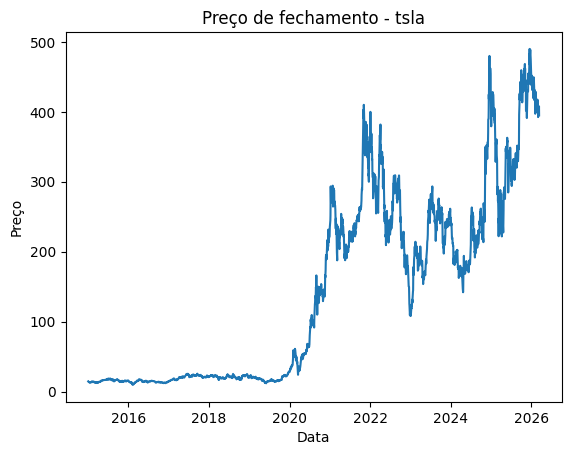

In [8]:
#3 visualização dos graficos do titanic
plt.figure()
plt.plot(series)
plt.title(f"Preço de fechamento - {ticker}")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.show()

In [9]:
#4 Normalização dos dados
scaler = MinMaxScaler(feature_range=(0,1))
series_scaled = scaler.fit_transform(series)
print(series_scaled)

[[0.01049895]
 [0.0092192 ]
 [0.00938437]
 ...
 [0.81128537]
 [0.82914917]
 [0.80247845]]


In [10]:
#5 Criação das janelas temporais
def create_window(data, window_size):
  X, y = [], []
  for i in range(len(data) - window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])
  return np.array(X), np.array(y)

In [11]:
window_size = 30

X, y = create_window(series_scaled, window_size)

print(f"Formato do x: {X.shape}")
print(f"Formato do y: {y.shape}")

Formato do x: (2784, 30, 1)
Formato do y: (2784, 1)


In [12]:
#6 Seperação treino / teste(sem embaralhar)
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (2227, 30, 1)
Teste: (557, 30, 1)


In [13]:
# 7 - construção do modelo lstm
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(
    optimizer="adam",
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#8 Treinamento do modelo
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 50,
    restore_best_weights = True
)


In [21]:
history = model.fit (
    X_train,
    y_train,
    batch_size = 50,
    epochs = 120,
    validation_split = 0.2,
    callbacks = [early_stop],
    verbose = 2
)

Epoch 1/120
36/36 - 0s - 11ms/step - loss: 1.1997e-04 - val_loss: 4.3986e-04
Epoch 2/120
36/36 - 0s - 11ms/step - loss: 1.3272e-04 - val_loss: 3.5823e-04
Epoch 3/120
36/36 - 0s - 12ms/step - loss: 1.1820e-04 - val_loss: 3.9084e-04
Epoch 4/120
36/36 - 1s - 18ms/step - loss: 1.1101e-04 - val_loss: 3.4844e-04
Epoch 5/120
36/36 - 0s - 12ms/step - loss: 1.0567e-04 - val_loss: 3.7773e-04
Epoch 6/120
36/36 - 0s - 13ms/step - loss: 1.0749e-04 - val_loss: 3.5249e-04
Epoch 7/120
36/36 - 0s - 11ms/step - loss: 1.1270e-04 - val_loss: 3.5976e-04
Epoch 8/120
36/36 - 0s - 11ms/step - loss: 1.0729e-04 - val_loss: 3.4683e-04
Epoch 9/120
36/36 - 0s - 11ms/step - loss: 1.0498e-04 - val_loss: 4.1089e-04
Epoch 10/120
36/36 - 0s - 11ms/step - loss: 1.1271e-04 - val_loss: 3.4618e-04
Epoch 11/120
36/36 - 0s - 11ms/step - loss: 1.0338e-04 - val_loss: 5.5733e-04
Epoch 12/120
36/36 - 0s - 11ms/step - loss: 1.1941e-04 - val_loss: 3.4175e-04
Epoch 13/120
36/36 - 0s - 12ms/step - loss: 1.0943e-04 - val_loss: 3.4392

In [17]:
# 9. avaliação do modelo
y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"RMSE: {rmse}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
RMSE: 12.714700487290562


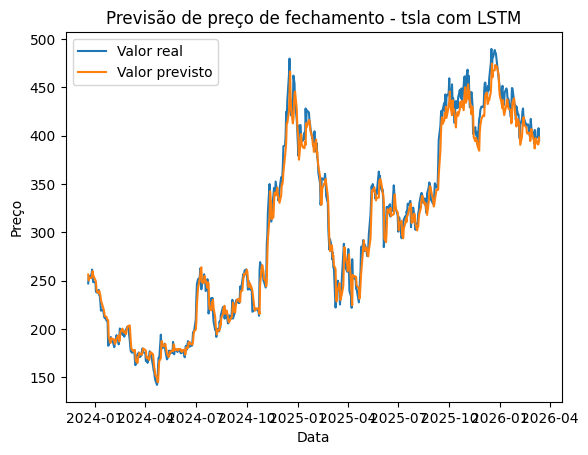

In [18]:
# 10. Visualização das previsões
plt.figure()
plt.plot(series.index[-len(y_test):] , y_test_inv, label="Valor real")
plt.plot(series.index[-len(y_test):], y_pred_inv, label="Valor previsto")
plt.title(f"Previsão de preço de fechamento - {ticker} com LSTM")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.show()

In [19]:
#11. Previsão de fechamento do próximo dia
last_window = series_scaled[-window_size:]
last_window = last_window.reshape(1, window_size, 1)

next_day_pred = model.predict(last_window) # valores entre 0 e 1
next_day_price = scaler.inverse_transform(next_day_pred) # valores previsto em dólares

print(f"Previão de preço da {ticker} para o proximo dia $ {next_day_price[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Previão de preço da tsla para o proximo dia $ 390.53
